# Importing libraries

In [1]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.inspection import permutation_importance
import seaborn as sns
from scipy.stats import norm
import statsmodels.api as sm
import pandas as pd
import numpy as np
import os
directory = os.getcwd()
parent_directory = os.path.dirname(directory)
%load_ext rpy2.ipython

In [2]:
%%R  -w 8 -h 3 #--units in -r 200
##installing packages and setting options for the plots in R

# {r settings, echo=F, message=F, error=F}
knitr::opts_chunk$set(echo = F)
if (!require("pacman")) install.packages("pacman")
pacman::p_load(ggplot2, patchwork, cowplot, tidyverse, devtools, ggrepel, ggh4x, officer, rvg, svglite, install = T)

# # Required on the first run, comment afterward?
# devtools::install_github("BlakeRMills/MoMAColors")
library(MoMAColors)

theme_set(theme_cowplot() +
          theme(text = element_text(size=9),
                axis.text = element_text(size=9),
                panel.grid.major.x = element_blank() ,
                panel.grid.major.y = element_line( linewidth=.1, color="black")))

Loading required package: pacman


In [3]:
def extract_values(df):
    shapes = list(df['Unnamed: 0'])
    pairwise_distances = np.array(df[shapes])
    values = []
    for i in range(len(shapes)):
        for j in range(i):
            values.append(pairwise_distances[i,j])
    return np.array(values)

# Plot each model's correlation with behavior

In [4]:
dict_sizes = {'in1k' : int(1281167),
              'in22k' :int(14197122),
              'openai-400m' : int(400000000),
              'LVD-142M' : int(142000000),
              'LVD-1689M' : int(1700000000),
              'laion2b': int(2000000000),
              }

behavioral = extract_values(pd.read_csv(directory +'/RDMs/behavioral'))
symbolic = extract_values(pd.read_csv(directory +'/RDMs/symbolic'))
data = {
    'behavioral':behavioral,
    'symbolic':symbolic,
}
df = pd.DataFrame(data)
best_layers = []
models = []
base_dir = os.path.join(directory, 'RDMs')
count_last_best = 0
count_all = 0
for model in os.listdir(base_dir):
    if 'metric' in model:
        continue
    
    model_path = os.path.join(base_dir, model)
    if os.path.isdir(model_path):  # Ensure it's a folder
        # Find all files that match "layer_n"
        models.append(model)
        layer_files = [f for f in os.listdir(model_path) if f.startswith("layer_") and f[6:].isdigit()]

        layer_nums = {f: int(f.split("_")[1]) for f in layer_files}
        last_layer = max(layer_nums, key=layer_nums.get)
        max_corr = -np.inf
        best_layer = None
        best_rdm = None
        layer_files = sorted(layer_files, key=lambda x: int(x.split("_")[1]))
        for layer in layer_files:
            file_path = os.path.join(model_path, layer)
            layer_rdm = extract_values(pd.read_csv(file_path))
            corr = np.corrcoef(layer_rdm, behavioral)[0, 1]
            if corr >= max_corr:
                max_corr = corr
                best_layer = layer
                best_rdm = layer_rdm
        # Save best RDM to df
        df[model] = best_rdm

        # Update counts
        count_all += 1
        if best_layer == last_layer:
            count_last_best += 1
        if not best_layer == last_layer:
            print(model)
            print(best_layer)
        best_layers.append(best_layer)

# Final proportion
proportion_last_best = count_last_best / count_all if count_all > 0 else 0
print(f"Proportion of models where best layer is last: {proportion_last_best:.2f}")

dinov3_convnext_tiny
layer_4
dinov3_huge
layer_29
vit_base_patch16_clip_224.laion2b
layer_10
vit_base_patch16_clip_224.openai
layer_9
vit_huge_patch14_clip_224.laion2b
layer_24
dino_base
layer_12
vit_giant_patch14_clip_224.laion2b
layer_28
vit_large_patch14_clip_224.laion2b
layer_19
dinov3_7b
layer_35
vit_small_patch16_224.dino
layer_9
dino_small
layer_12
vit_large_patch14_clip_224.openai
layer_17
vit_base_patch16_224.dino
layer_6
dino_large
layer_24
vit_base_patch16_224.augreg_in1k
layer_8
Proportion of models where best layer is last: 0.67


In [5]:
df_layers = pd.DataFrame({
    'model':models,
    'best_layer':best_layers
})
df_layers.to_csv('df_layers.csv')

In [6]:
corr = df.corr()
metadata = pd.read_csv(parent_directory +'/utils/metadata_models.csv')
metadata_clean = metadata.transpose().reset_index()
metadata_clean.dropna(inplace=True)
def clean_number(n):
    num = int(n)//1000000
    return f'{num}M'
# metadata_clean[0] = metadata_clean[0].apply(clean_number)
def classify_backbone(name):
    if 'convnext' in name:
        return "cnn"
    elif name.startswith(("vit", "dino", "clip")):
        return "vit"
    else:
        return "cnn"

metadata_clean["backbone"] = metadata_clean['index'].apply(classify_backbone)



In [7]:
a = metadata.transpose().reset_index()
b = corr.head(1).transpose().reset_index()
df_plot = pd.merge(metadata_clean, b, how='outer')
df_plot.columns = ['model', 'number_parameters', 'train_set', 'backbone','correlation', ]
df_plot['train_set_size'] = df_plot.train_set.apply(lambda x: dict_sizes[x] if pd.notna(x) else None)
df_plot = df_plot.dropna()
df_plot['number_parameters'] = df_plot.number_parameters.apply(lambda x: int(x))


# Compute the log of the number of parameters
df_plot['log_number_parameters'] = np.log10(df_plot['number_parameters'])
df_plot['sqrt_number_parameters'] = np.sqrt(df_plot['number_parameters'])


## Compute a function of the number of parameters for the plot, such that the smallest points are visible and the biggests don't take the whole screen
chosen_power = 2/3 

df_plot['power_number_parameters'] = np.power(df_plot['number_parameters'], chosen_power)
df_plot['power_number_parameters'] = np.where(df_plot['number_parameters'] > 5e9, df_plot['power_number_parameters'] / 1.5, df_plot['power_number_parameters'])

conditions = [
    df_plot['model'].str.contains('dino', case=False, na=False),
    df_plot['model'].str.contains('clip', case=False, na=False)
]
choices = ['unsupervised', 'clip']

df_plot['training_method'] = np.select(conditions, choices, default='supervised')
df_plot.to_csv('all_cors.csv',index=False)

In [8]:
features = ['number_parameters', 'train_set_size', 'backbone', 'training_method']

df_features = pd.get_dummies(
    df_plot[features],
    columns=['backbone', 'training_method'],
    drop_first=False
)

[Text(1000000.0, 0, '$\\mathdefault{10^{6}}$'), Text(10000000.0, 0, '$\\mathdefault{10^{7}}$'), Text(100000000.0, 0, '$\\mathdefault{10^{8}}$'), Text(1000000000.0, 0, '$\\mathdefault{10^{9}}$'), Text(10000000000.0, 0, '$\\mathdefault{10^{10}}$')]


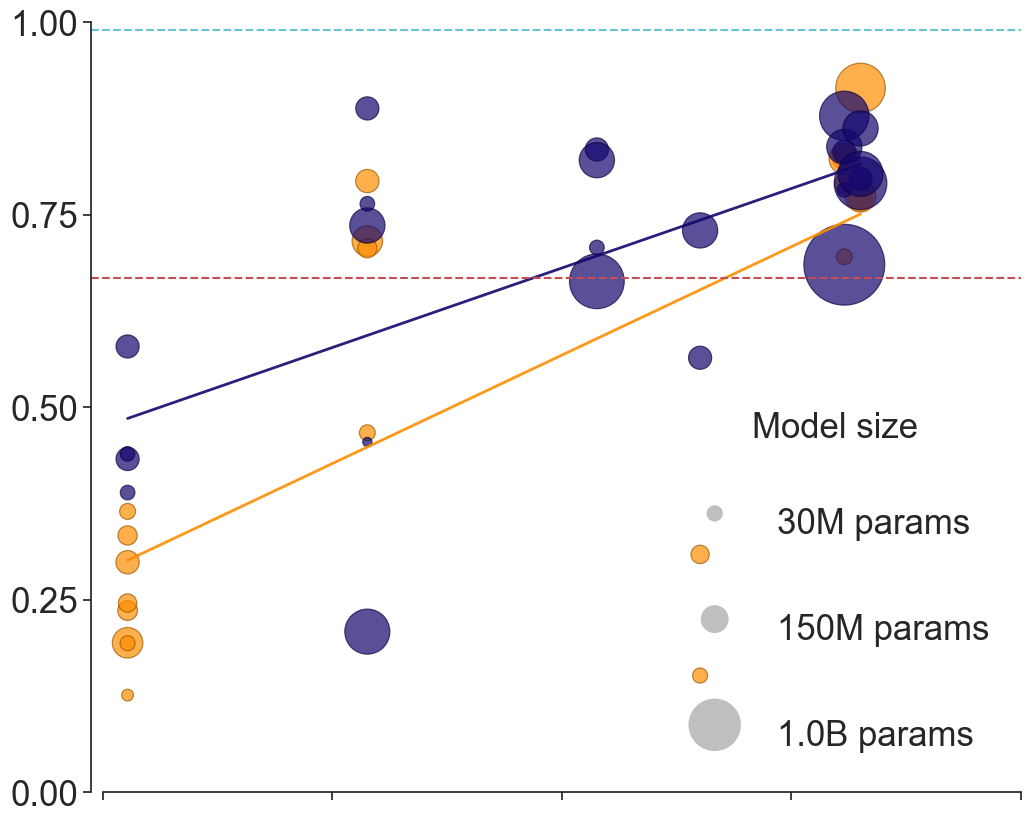

In [9]:
symbolic_corr = 0.667
noise_ceiling = 0.99
def adjust_lightness(color, amount=0.5):
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], c[1] * amount, c[2])

palette = {

    ('cnn'): '#ff8d00',
    ('vit'): '#13066d',  
 
}
df_plot['color'] = df_plot.apply(lambda row: palette[(row['backbone'])], axis=1)
df_plot['edge_color']  = [adjust_lightness(color, 0.6) for color in list(df_plot['color'])]

scale_factor = 700
# Plotting with custom colors
sns.set(style='white')
fig, ax = plt.subplots(figsize= (12, 10))
for (train), group_data in df_plot.groupby(['backbone']):
    sns.scatterplot(
        data=group_data,
        x='train_set_size',
        y='correlation',
        color=group_data['color'].iloc[0],
        edgecolor=group_data['edge_color'].iloc[0],
        s=group_data['power_number_parameters'] /scale_factor,  # Size proportional to number_parameters
        alpha=0.7,
        legend=False
    )

size_legend_params = [30_000_000, 150_000_000, 1_000_000_000]  # adjust based on your actual model sizes
size_legend_dots = [np.power(s, chosen_power)/scale_factor for s in size_legend_params]

legend_elements = [
    plt.scatter([], [], s=size, color='gray', alpha=0.5, edgecolors='none',
                label=f'{p/1e9:.1f}B params' if p >= 1e9 else f'{int(p/1e6)}M params')
    for size, p in zip(size_legend_dots, size_legend_params)
]

# Place the legend
ax.legend(
    handles=legend_elements,
    title='Model size',
    loc='lower right',
    fontsize=25,
    title_fontsize=25,
    handleheight=2,
    labelspacing=1.5,
    frameon=False
)


for backbone, group_data in df_plot.groupby("backbone"):
    # Log-transform X
    X = np.log10(group_data["train_set_size"]).values.reshape(-1, 1)
    y = group_data["correlation"].values

    # Fit regression
    reg = LinearRegression().fit(X, y)

    # Make smooth prediction line
    x_range = np.linspace(group_data["train_set_size"].min(),
                          group_data["train_set_size"].max(), 200)
    x_range_log = np.log10(x_range).reshape(-1, 1)
    y_pred = reg.predict(x_range_log)

    # Plot regression line with the same color as the scatter
    ax.plot(
        x_range,
        y_pred,
        color=palette[backbone],
        linewidth=2,
        linestyle="-",
        alpha=0.9,
    )
handles, labels = [],[]
plt.xscale('log')
# Customize labels and ticks
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticks([1e6, 1e7, 1e8, 1e9, 1e10])
yticks = ax.get_yticklabels()
xticks = ax.get_xticklabels()
print(xticks)
noise_ceiling = 0.99
plt.axhline(y=symbolic_corr, color='r', linestyle='--',)
plt.axhline(y=noise_ceiling, color='#68C3D4', linestyle='--',)

ax.set_ylabel("")
ax.set_xlabel("")

ax.set_yticklabels(yticks, size=25)
ax.set_xticklabels([], size=25)

ax.spines['left'].set_bounds(0, 1.0)
ax.spines['bottom'].set_bounds(1e6, 1e10)
ax.tick_params(left=True, bottom=True)

sns.despine()
plt.rcParams['svg.fonttype'] = 'none'
fig.savefig('plots/figure_rsa_quadri.svg', format='svg')

In [53]:
features = ['number_parameters', 'train_set_size', 'backbone', 'training_method']
target = 'correlation'
df_plot = pd.read_csv('all_cors.csv')
# One-hot encode categorical variables: backbone and training_method
df_features = pd.get_dummies(
    df_plot[features],
    columns=['backbone', 'training_method'],
    drop_first=False
)

# Standardize numerical features
scaler = StandardScaler()
df_features[['number_parameters', 'train_set_size']] = scaler.fit_transform(
    df_features[['number_parameters', 'train_set_size']]
)

X = df_features
y = df_plot[target]

color_significant = '#5A509B'
color_non_significant = '#888'

# Fit Ridge regression
model = Ridge(alpha=1e-2).fit(X, y)
print(model.score(X, y))


0.5137628726945918


In [54]:
def grouped_permutation_importance(model, X, y, groups, n_repeats=30, random_state=0):
    rng = np.random.RandomState(random_state)
    baseline_score = model.score(X, y)
    n_groups = len(groups)

    importances = {}

    for group in groups:
        print(group)
        scores = []
        for _ in range(n_repeats):
            X_permuted = X.copy()
            # permute all columns in this group together
            idx = rng.permutation(len(X))
            X_permuted[group] = X_permuted[group].iloc[idx].values
            scores.append(model.score(X_permuted, y))

        scores = np.array([float(s) for s in scores])
        drops = baseline_score - scores
        mean_drop = np.mean(drops)
        std_drop = np.std(drops)


        m = len(groups)  # number of features
        alpha = 0.05

        # Bonferroni-adjusted z threshold
        z_adj = norm.ppf(1 - alpha / (2*m))
      
        significant = abs(mean_drop) > z_adj * std_drop

        importances[group[0]] = {'mean': mean_drop, 'std': std_drop, 'significant':significant}
       
    return importances



# Example: group dummies for training_method
groups = [
    [col for col in X.columns if col.startswith("training_method_")],
    [col for col in X.columns if col.startswith("backbone_")],
    ['number_parameters'],
    ['train_set_size']
]

importances = grouped_permutation_importance(model, X, y, groups)
feature_importance = pd.DataFrame(importances)
print(feature_importance)
feature_importance2 = feature_importance.T
# Assign colors
feature_importance2['Color'] = feature_importance2['significant'].map(
    {True: color_significant, False: color_non_significant}
)
feature_importance2['Feature'] = feature_importance2.index
feature_importance2.reset_index()

print(feature_importance2)
feature_importance2
feature_importance2.to_csv('temp.csv')

['training_method_clip', 'training_method_supervised', 'training_method_unsupervised']
['backbone_cnn', 'backbone_vit']
['number_parameters']
['train_set_size']
            training_method_clip backbone_cnn number_parameters train_set_size
mean                    0.048478     0.251113          0.024557       0.924038
std                     0.033352     0.077149          0.029427       0.195232
significant                False         True             False           True
                          mean       std significant    Color  \
training_method_clip  0.048478  0.033352       False     #888   
backbone_cnn          0.251113  0.077149        True  #5A509B   
number_parameters     0.024557  0.029427       False     #888   
train_set_size        0.924038  0.195232        True  #5A509B   

                                   Feature  
training_method_clip  training_method_clip  
backbone_cnn                  backbone_cnn  
number_parameters        number_parameters  
train_set_size   

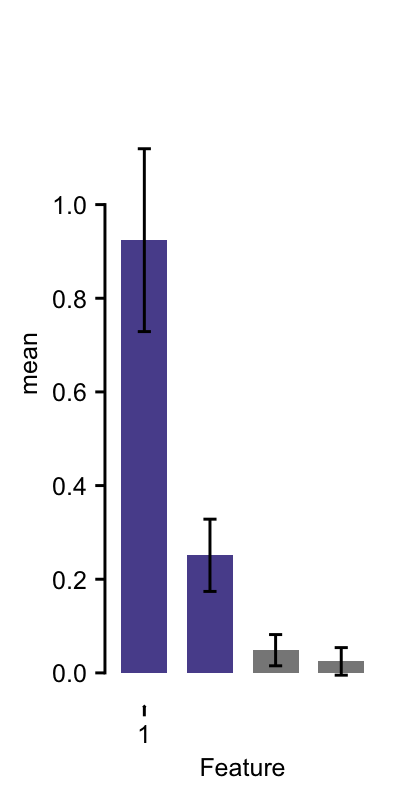

In [55]:
%%R -w 2 -h 4  --units in -r 200

feature_importance <- read.csv('temp.csv')
feature_importance <- feature_importance %>%
  arrange(desc(mean))

feature_importance$Feature <- factor(feature_importance$Feature, levels = feature_importance$Feature)

# Create the ggplot2 bar plot
p <- ggplot(feature_importance, aes(x = Feature, y = mean, fill = Color)) +
    geom_col(width = 0.7) + # geom_col for pre-computed heights, width adjusts bar thickness
    geom_errorbar(
      aes(ymin = mean - std, ymax = mean + std),
      width = 0.2, # Adjust the width of the error bar caps
      color = "black" # Color of the error bars
    ) +
    scale_fill_identity() + # Use the 'Color' column directly for fill
    # Customizing the theme for a "prettier" look and removing top/right spines
    # theme_minimal() + # Start with a minimal theme
    theme(
      panel.grid.major = element_blank(), # Remove major grid lines
      panel.grid.minor = element_blank(), # Remove minor grid lines
      panel.background = element_blank(), 
      panel.grid.major.y = element_blank(),

    ) +
    # Set y-axis limits and breaks similar to your Python code
    # The Python y-axis was inverted, but for means, a standard positive up is usually preferred.
    # If you truly want to invert, you'd use scale_y_reverse().
  

    guides(x = guide_axis_manual(trunc_lower=1, trunc_upper=1, breaks=c(1)),
          y = guide_axis_manual(trunc_lower=0, trunc_upper=1.0, breaks=seq(0,1.0,0.2))) +


    coord_cartesian(ylim = c(min(feature_importance$mean - feature_importance$std) * 1.1,
                            max(feature_importance$mean + feature_importance$std) * 1.1 + max(feature_importance$std) * 0.5)
                    )  # This helps control the visible range without dropping data

  
    # coord_flip(ylim = c(
    #   min(feature_importance$mean - feature_importance$std) * 1.1,
    #   max(feature_importance$mean + feature_importance$std) * 1.1 + max(feature_importance$std) * 0.5
    # ))
  
ggsave("plots/feature_importance.svg", p, device='svg',width = 2, height = 4, units = "in")
p

# Contribution of different models

In [13]:
rdm_dino = extract_values(pd.read_csv('RDMs/dinov3_huge/layer_29'))
rdm_cornet = extract_values(pd.read_csv('RDMs/cornet/layer_3'))
rdm_symbolic = extract_values(pd.read_csv('RDMs/symbolic'))
rdm_behavioral = extract_values(pd.read_csv('RDMs/behavioral'))

In [14]:
# Combine predictors into a DataFrame
X = pd.DataFrame({
    'dino': rdm_dino,
    'cornet': rdm_cornet,
    'symbolic': rdm_symbolic
})

y = rdm_behavioral

# Normalize predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit linear regression
model = LinearRegression()
model.fit(X_scaled, y)

# Get coefficients
coefficients = pd.Series(model.coef_, index=X.columns)
print("Regression coefficients:")
print(coefficients)

Regression coefficients:
dino        0.124756
cornet     -0.009945
symbolic   -0.011618
dtype: float64


In [15]:
X = pd.DataFrame({
    'dino': rdm_dino,
    'cornet': rdm_cornet,
    'symbolic': rdm_symbolic
})
y = rdm_behavioral

# Normalize predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Add constant term for intercept (required by statsmodels)
X_scaled = sm.add_constant(X_scaled)

# Fit OLS regression
model = sm.OLS(y, X_scaled).fit()

# Summary includes coefficients, R², and p-values
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.779
Model:                            OLS   Adj. R-squared:                  0.766
Method:                 Least Squares   F-statistic:                     59.79
Date:                Fri, 24 Oct 2025   Prob (F-statistic):           1.03e-16
Time:                        15:34:30   Log-Likelihood:                 76.614
No. Observations:                  55   AIC:                            -145.2
Df Residuals:                      51   BIC:                            -137.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2596      0.008     30.856      0.0

In [16]:
model.pvalues

array([1.16297148e-34, 1.49948955e-11, 2.73978002e-01, 4.07449900e-01])

In [17]:
# Compute correlation matrix
corr_matrix = X.corr()

print("Correlation matrix of predictors:")
print(corr_matrix)


Correlation matrix of predictors:
              dino    cornet  symbolic
dino      1.000000  0.341031  0.794101
cornet    0.341031  1.000000  0.215641
symbolic  0.794101  0.215641  1.000000


# Layerwise analysis

In [18]:
original_corrs = []
base_dir = os.path.join(directory, 'RDMs/dinov3_small')
behavioral = extract_values(pd.read_csv(directory +'/RDMs/behavioral'))

# Store paths to layer files to process them once
layer_file_paths = []
if os.path.isdir(base_dir):
    layer_files = [f for f in os.listdir(base_dir) if f.startswith("layer_") and f[6:].isdigit()]
    for layer_file in sorted(layer_files, key=lambda x: int(x[6:])):
        layer_file_paths.append(os.path.join(base_dir, layer_file))

# Load all layer RDMs once to avoid re-reading in the loop
model_rdms = [extract_values(pd.read_csv(f)) for f in layer_file_paths]
layers = [int(os.path.basename(f)[6:]) for f in layer_file_paths] # Get layer numbers

model_rdms = model_rdms[:-1]
layers = layers[:-1]
layers = [(i)/(len(layers)-1) for i in layers]
# Calculate original correlations
for model_rdm in model_rdms:
    corr = np.corrcoef(model_rdm, behavioral)[0,1]
    original_corrs.append(corr)




# Create DataFrame for original correlations
df_original = pd.DataFrame({'layer': layers, 'correlation': original_corrs})

In [19]:
original_corrs = []
base_dir = os.path.join(directory, 'RDMs/vit_giant_patch14_clip_224.laion2b')
behavioral = extract_values(pd.read_csv(directory +'/RDMs/behavioral'))

# Store paths to layer files to process them once
layer_file_paths = []
if os.path.isdir(base_dir):
    layer_files = [f for f in os.listdir(base_dir) if f.startswith("layer_") and f[6:].isdigit()]
    for layer_file in sorted(layer_files, key=lambda x: int(x[6:])):
        layer_file_paths.append(os.path.join(base_dir, layer_file))

# Load all layer RDMs once to avoid re-reading in the loop
model_rdms = [extract_values(pd.read_csv(f)) for f in layer_file_paths]
layers = [int(os.path.basename(f)[6:]) for f in layer_file_paths] # Get layer numbers

# model_rdms = model_rdms[:-1]
# layers = layers[:-1]
layers = [(i)/(len(layers)-1) for i in layers]
# Calculate original correlations
for model_rdm in model_rdms:
    corr = np.corrcoef(model_rdm, behavioral)[0,1]
    original_corrs.append(corr)




# Create DataFrame for original correlations
df_2 = pd.DataFrame({'layer': layers, 'correlation': original_corrs})

In [20]:
original_corrs = []
base_dir = os.path.join(directory, 'RDMs/convnext_xxlarge.clip_laion2b_soup')
behavioral = extract_values(pd.read_csv(directory +'/RDMs/behavioral'))

# Store paths to layer files to process them once
layer_file_paths = []
if os.path.isdir(base_dir):
    layer_files = [f for f in os.listdir(base_dir) if f.startswith("layer_") and f[6:].isdigit()]
    for layer_file in sorted(layer_files, key=lambda x: int(x[6:])):
        layer_file_paths.append(os.path.join(base_dir, layer_file))

# Load all layer RDMs once to avoid re-reading in the loop
model_rdms = [extract_values(pd.read_csv(f)) for f in layer_file_paths]
layers = [int(os.path.basename(f)[6:]) for f in layer_file_paths] # Get layer numbers

# model_rdms = model_rdms[:-1]
# layers = layers[:-1]
layers = [(i)/(len(layers)-1) for i in layers]
# Calculate original correlations
for model_rdm in model_rdms:
    corr = np.corrcoef(model_rdm, behavioral)[0,1]
    original_corrs.append(corr)




# Create DataFrame for original correlations
df_3 = pd.DataFrame({'layer': layers, 'correlation': original_corrs})

/var/folders/yr/1hvrtjdn3hzc_7rf_6kpdl69v063g3/T/ipykernel_3225/3644875343.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


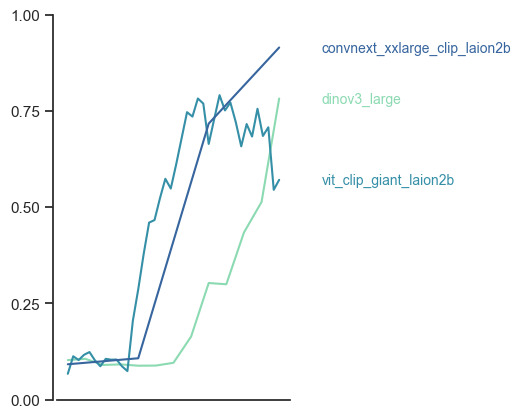

In [21]:
fig, ax = plt.subplots(figsize=(3, 5))
palette = sns.color_palette("mako_r", as_cmap=False)

models = [
    'dinov3_large',
    'vit_clip_giant_laion2b',
    'convnext_xxlarge_clip_laion2b',
]

# Plot each line
sns.lineplot(data=df_original, y='correlation', x='layer', color=palette[0], ax=ax)
sns.lineplot(data=df_2, y='correlation', x='layer', color=palette[2], ax=ax)
sns.lineplot(data=df_3, y='correlation', x='layer', color=palette[3], ax=ax)
# sns.lineplot(data=df_4, y='correlation', x='layer', color=palette[4], ax=ax)

# Add labels at the end of each line
dfs = [df_original, df_2, df_3]
colors = [palette[0], palette[2], palette[3], palette[4]]

for df, label, color in zip(dfs, models, colors):
    x = df['layer'].max()  # last x value
    y = df.loc[df['layer'].idxmax(), 'correlation']  # y at last x
    ax.text(
        x + 0.2, y, label,
        color=color, fontsize=10, va='center'
    )

# Formatting
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
yticks = ax.get_yticklabels()
ax.set_ylabel("")
ax.set_yticklabels(yticks, size=12)
ax.spines['left'].set_bounds(0, 1)
ax.tick_params(left=True, bottom=False)
ax.get_xaxis().set_visible(False)   
ax.spines['left'].set_position(('outward', 3))  
sns.despine()

plt.legend().remove()
fig.savefig('plots/corr_layers.svg', format='svg')


# With other metric

In [36]:
dict_sizes = {'in1k' : int(1281167),
              'in22k' :int(14197122),
              'openai-400m' : int(400000000),
              'LVD-142M' : int(142000000),
              'LVD-1689M' : int(1700000000),
              'laion2b': int(2000000000),
              }

behavioral = extract_values(pd.read_csv(directory +'/RDMs/behavioral'))
# symbolic = extract_values(pd.read_csv(directory +'/RDMs/symbolic'))
data = {
    'behavioral':behavioral,
    # 'symbolic':symbolic,
}
df = pd.DataFrame(data)
best_layers = []
models = []
base_dir = os.path.join(directory, 'RDMs/z_other_metrics/cosine')
count_last_best = 0
count_all = 0
for model in os.listdir(base_dir):
    # print(model)
    models.append(model)
    model_path = os.path.join(base_dir, model)
    if os.path.isdir(model_path):  # Ensure it's a folder
        # Find all files that match "layer_n"
        layer_files = [f for f in os.listdir(model_path) if f.startswith("layer_") and f[6:].isdigit()]

        layer_nums = {f: int(f.split("_")[1]) for f in layer_files}
        last_layer = max(layer_nums, key=layer_nums.get)
        max_corr = -np.inf
        best_layer = None
        best_rdm = None
        layer_files = sorted(layer_files, key=lambda x: int(x.split("_")[1]))
        for layer in layer_files:
            file_path = os.path.join(model_path, layer)
            layer_rdm = extract_values(pd.read_csv(file_path))
            corr = np.corrcoef(layer_rdm, behavioral)[0, 1]
            if corr >= max_corr:
                max_corr = corr
                best_layer = layer
                best_rdm = layer_rdm
        # Save best RDM to df
        df[model] = best_rdm

        # Update counts
        count_all += 1
        if best_layer == last_layer:
            count_last_best += 1
        if not best_layer == last_layer:
            print(model)
            print(best_layer)
        best_layers.append(best_layer)

# Final proportion
proportion_last_best = count_last_best / count_all if count_all > 0 else 0
print(f"Proportion of models where best layer is last: {proportion_last_best:.2f}")

vit_tiny_in22k
layer_11
dinov3_convnext_tiny
layer_4
dinov3_huge
layer_31
vit_base_patch16_clip_224.laion2b
layer_10
vit_base_patch16_clip_224.openai
layer_9
vit_huge_patch14_clip_224.laion2b
layer_30
dino_base
layer_12
vit_giant_patch14_clip_224.laion2b
layer_25
vit_large_patch14_clip_224.laion2b
layer_19
dinov3_7b
layer_36
dinov3_convnext_small
layer_4
dino_small
layer_12
vit_large_patch14_clip_224.openai
layer_17
dino_large
layer_24
vit_base_patch16_224.augreg_in1k
layer_8
Proportion of models where best layer is last: 0.65


In [37]:
corr = df.corr()
metadata = pd.read_csv(parent_directory +'/utils/metadata_models.csv')
metadata_clean = metadata.transpose().reset_index()
metadata_clean.dropna(inplace=True)
def clean_number(n):
    num = int(n)//1000000
    return f'{num}M'
# metadata_clean[0] = metadata_clean[0].apply(clean_number)
def classify_backbone(name):
    if 'convnext' in name:
        return "cnn"
    elif name.startswith(("vit", "dino", "clip")):
        return "vit"
    else:
        return "cnn"

metadata_clean["backbone"] = metadata_clean['index'].apply(classify_backbone)


a = metadata.transpose().reset_index()
b = corr.head(1).transpose().reset_index()
df_plot = pd.merge(metadata_clean, b, how='outer')
df_plot.columns = ['model', 'number_parameters', 'train_set', 'backbone','correlation', ]
df_plot['train_set_size'] = df_plot.train_set.apply(lambda x: dict_sizes[x] if pd.notna(x) else None)
df_plot = df_plot.dropna()
df_plot['number_parameters'] = df_plot.number_parameters.apply(lambda x: int(x))


# Compute the log of the number of parameters
df_plot['log_number_parameters'] = np.log10(df_plot['number_parameters'])
df_plot['sqrt_number_parameters'] = np.sqrt(df_plot['number_parameters'])

## Compute a function of the number of parameters for the plot, such that the smallest points are visible and the biggests don't take the whole screen
chosen_power = 2/3 

df_plot['power_number_parameters'] = np.power(df_plot['number_parameters'], chosen_power)
df_plot['power_number_parameters'] = np.where(df_plot['number_parameters'] > 5e9, df_plot['power_number_parameters'] / 1.5, df_plot['power_number_parameters'])

conditions = [
    df_plot['model'].str.contains('dino', case=False, na=False),
    df_plot['model'].str.contains('clip', case=False, na=False)
]
choices = ['unsupervised', 'clip']

df_plot['training_method'] = np.select(conditions, choices, default='supervised')
# df_plot.to_csv('all_cors.csv',index=False)

[Text(1000000.0, 0, '$\\mathdefault{10^{6}}$'), Text(10000000.0, 0, '$\\mathdefault{10^{7}}$'), Text(100000000.0, 0, '$\\mathdefault{10^{8}}$'), Text(1000000000.0, 0, '$\\mathdefault{10^{9}}$'), Text(10000000000.0, 0, '$\\mathdefault{10^{10}}$')]


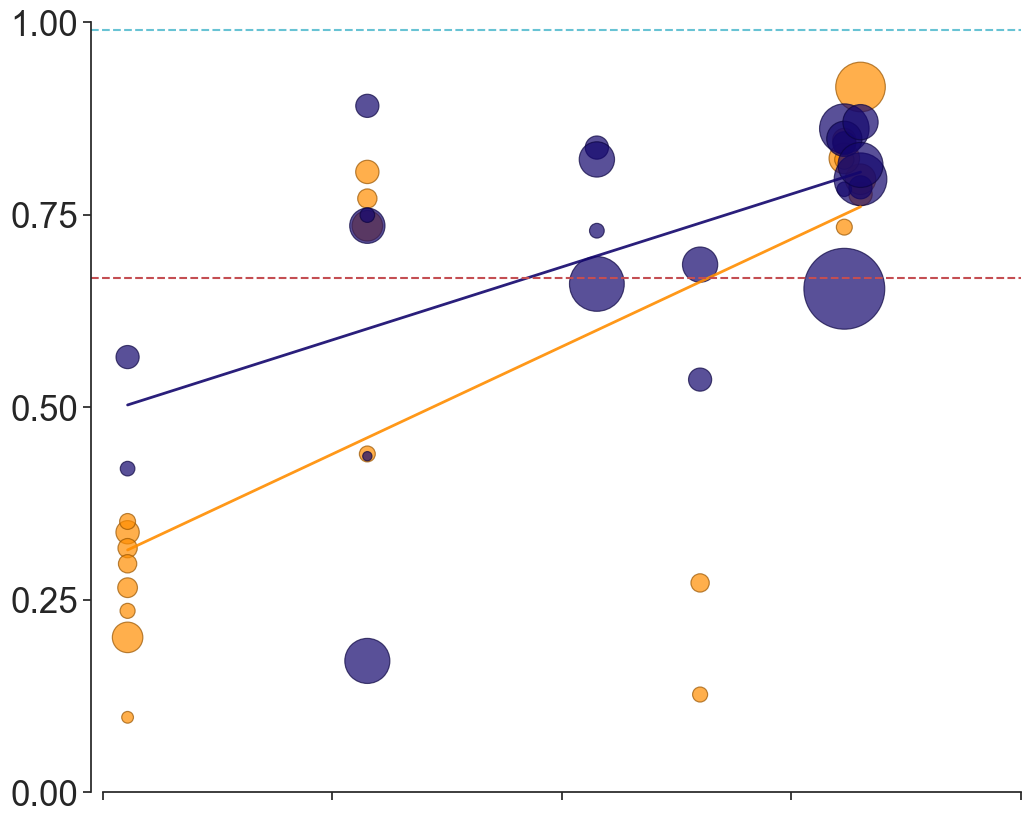

In [39]:
symbolic_corr = 0.667
noise_ceiling = 0.99
def adjust_lightness(color, amount=0.5):
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], c[1] * amount, c[2])

palette = {

    ('cnn'): '#ff8d00',
    ('vit'): '#13066d',  
 
}
df_plot['color'] = df_plot.apply(lambda row: palette[(row['backbone'])], axis=1)
df_plot['edge_color']  = [adjust_lightness(color, 0.6) for color in list(df_plot['color'])]

scale_factor = 700
# Plotting with custom colors
sns.set(style='white')
fig, ax = plt.subplots(figsize= (12, 10))
for (train), group_data in df_plot.groupby(['backbone']):
    sns.scatterplot(
        data=group_data,
        x='train_set_size',
        y='correlation',
        color=group_data['color'].iloc[0],
        edgecolor=group_data['edge_color'].iloc[0],
        s=group_data['power_number_parameters'] /scale_factor,  # Size proportional to number_parameters
        alpha=0.7,
        legend=False
    )

# size_legend_params = [30_000_000, 150_000_000, 1_000_000_000]  # adjust based on your actual model sizes
# size_legend_dots = [np.power(s, chosen_power)/scale_factor for s in size_legend_params]

# legend_elements = [
#     plt.scatter([], [], s=size, color='gray', alpha=0.5, edgecolors='none',
#                 label=f'{p/1e9:.1f}B params' if p >= 1e9 else f'{int(p/1e6)}M params')
#     for size, p in zip(size_legend_dots, size_legend_params)
# ]

# # Place the legend
# ax.legend(
#     handles=legend_elements,
#     title='Model size',
#     loc='lower right',
#     fontsize=25,
#     title_fontsize=25,
#     handleheight=2,
#     labelspacing=1.5,
#     frameon=False
# )


for backbone, group_data in df_plot.groupby("backbone"):
    # Log-transform X
    X = np.log10(group_data["train_set_size"]).values.reshape(-1, 1)
    y = group_data["correlation"].values

    # Fit regression
    reg = LinearRegression().fit(X, y)

    # Make smooth prediction line
    x_range = np.linspace(group_data["train_set_size"].min(),
                          group_data["train_set_size"].max(), 200)
    x_range_log = np.log10(x_range).reshape(-1, 1)
    y_pred = reg.predict(x_range_log)

    # Plot regression line with the same color as the scatter
    ax.plot(
        x_range,
        y_pred,
        color=palette[backbone],
        linewidth=2,
        linestyle="-",
        alpha=0.9,
    )
handles, labels = [],[]
plt.xscale('log')
# Customize labels and ticks
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticks([1e6, 1e7, 1e8, 1e9, 1e10])
yticks = ax.get_yticklabels()
xticks = ax.get_xticklabels()
print(xticks)
noise_ceiling = 0.99
plt.axhline(y=symbolic_corr, color='r', linestyle='--',)
plt.axhline(y=noise_ceiling, color='#68C3D4', linestyle='--',)

ax.set_ylabel("")
ax.set_xlabel("")

ax.set_yticklabels(yticks, size=25)
ax.set_xticklabels([], size=25)

ax.spines['left'].set_bounds(0, 1.0)
ax.spines['bottom'].set_bounds(1e6, 1e10)
ax.tick_params(left=True, bottom=True)

sns.despine()
plt.rcParams['svg.fonttype'] = 'none'
fig.savefig('plots/figure_rsa_quadri_cosine.svg', format='svg')

In [40]:
features = ['number_parameters', 'train_set_size', 'backbone', 'training_method']
target = 'correlation'
# df_plot = pd.read_csv('all_cors.csv')
# One-hot encode categorical variables: backbone and training_method
df_features = pd.get_dummies(
    df_plot[features],
    columns=['backbone', 'training_method'],
    drop_first=False
)

# Standardize numerical features
scaler = StandardScaler()
df_features[['number_parameters', 'train_set_size']] = scaler.fit_transform(
    df_features[['number_parameters', 'train_set_size']]
)

X = df_features
y = df_plot[target]

color_significant = '#5A509B'
color_non_significant = '#888'

# Fit Ridge regression
model = Ridge(alpha=1e-2).fit(X, y)
print(model.score(X, y))

def grouped_permutation_importance(model, X, y, groups, n_repeats=30, random_state=0):
    rng = np.random.RandomState(random_state)
    baseline_score = model.score(X, y)
    n_groups = len(groups)

    importances = {}

    for group in groups:
        print(group)
        scores = []
        for _ in range(n_repeats):
            X_permuted = X.copy()
            # permute all columns in this group together
            idx = rng.permutation(len(X))
            X_permuted[group] = X_permuted[group].iloc[idx].values
            scores.append(model.score(X_permuted, y))

        scores = np.array([float(s) for s in scores])
        drops = baseline_score - scores
        mean_drop = np.mean(drops)
        std_drop = np.std(drops)


        m = len(groups)  # number of features
        alpha = 0.05

        # Bonferroni-adjusted z threshold
        z_adj = norm.ppf(1 - alpha / (2*m))
      
        significant = abs(mean_drop) > z_adj * std_drop

        importances[group[0]] = {'mean': mean_drop, 'std': std_drop, 'significant':significant}
       
    return importances



# Example: group dummies for training_method
groups = [
    [col for col in X.columns if col.startswith("training_method_")],
    [col for col in X.columns if col.startswith("backbone_")],
    ['number_parameters'],
    ['train_set_size']
]

importances = grouped_permutation_importance(model, X, y, groups)
feature_importance = pd.DataFrame(importances)
print(feature_importance)
feature_importance2 = feature_importance.T
# Assign colors
feature_importance2['Color'] = feature_importance2['significant'].map(
    {True: color_significant, False: color_non_significant}
)
feature_importance2['Feature'] = feature_importance2.index
feature_importance2.reset_index()

print(feature_importance2)
feature_importance2
feature_importance2.to_csv('temp.csv')

0.5180725323982424
['training_method_clip', 'training_method_supervised', 'training_method_unsupervised']
['backbone_cnn', 'backbone_vit']
['number_parameters']
['train_set_size']
            training_method_clip backbone_cnn number_parameters train_set_size
mean                    0.099429     0.194277           0.04864       0.749921
std                     0.036055       0.0757          0.027234       0.161275
significant                 True         True             False           True
                          mean       std significant    Color  \
training_method_clip  0.099429  0.036055        True  #5A509B   
backbone_cnn          0.194277    0.0757        True  #5A509B   
number_parameters      0.04864  0.027234       False     #888   
train_set_size        0.749921  0.161275        True  #5A509B   

                                   Feature  
training_method_clip  training_method_clip  
backbone_cnn                  backbone_cnn  
number_parameters        number_parameters 

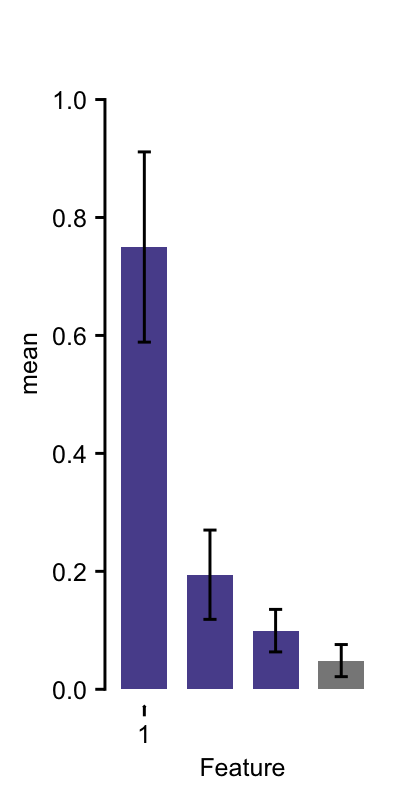

In [42]:
%%R -w 2 -h 4  --units in -r 200

feature_importance <- read.csv('temp.csv')
feature_importance <- feature_importance %>%
  arrange(desc(mean))

feature_importance$Feature <- factor(feature_importance$Feature, levels = feature_importance$Feature)

# Create the ggplot2 bar plot
p <- ggplot(feature_importance, aes(x = Feature, y = mean, fill = Color)) +
    geom_col(width = 0.7) + # geom_col for pre-computed heights, width adjusts bar thickness
    geom_errorbar(
      aes(ymin = mean - std, ymax = mean + std),
      width = 0.2, # Adjust the width of the error bar caps
      color = "black" # Color of the error bars
    ) +

    scale_fill_identity() + # Use the 'Color' column directly for fill
    # Customizing the theme for a "prettier" look and removing top/right spines
    # theme_minimal() + # Start with a minimal theme
    theme(
      panel.grid.major = element_blank(), # Remove major grid lines
      panel.grid.minor = element_blank(), # Remove minor grid lines
      panel.background = element_blank(), 
      panel.grid.major.y = element_blank(),

    ) +
    # Set y-axis limits and breaks similar to your Python code
    # The Python y-axis was inverted, but for means, a standard positive up is usually preferred.
    # If you truly want to invert, you'd use scale_y_reverse().
  

    guides(x = guide_axis_manual(trunc_lower=1, trunc_upper=1, breaks=c(1)),
          y = guide_axis_manual(trunc_lower=0, trunc_upper=1.0, breaks=seq(0,1.0,0.2))) +


    coord_cartesian(ylim = c(min(feature_importance$mean - feature_importance$std) * 1.1,
                            max(feature_importance$mean + feature_importance$std) * 1.1 + max(feature_importance$std) * 0.5)
                    )  # This helps control the visible range without dropping data

  
    # coord_flip(ylim = c(
    #   min(feature_importance$mean - feature_importance$std) * 1.1,
    #   max(feature_importance$mean + feature_importance$std) * 1.1 + max(feature_importance$std) * 0.5
    # ))
  
ggsave("plots/feature_importance_cosine.svg", p, device='svg',width = 2, height = 4, units = "in")
p

In [43]:
dict_sizes = {'in1k' : int(1281167),
              'in22k' :int(14197122),
              'openai-400m' : int(400000000),
              'LVD-142M' : int(142000000),
              'LVD-1689M' : int(1700000000),
              'laion2b': int(2000000000),
            #   'dfn2b': int(2000000000),
            #   '2pt5b': int(2500000000),
            #   'dfn5b': int(5000000000),
              }

behavioral = extract_values(pd.read_csv(directory +'/RDMs/behavioral'))
# symbolic = extract_values(pd.read_csv(directory +'/RDMs/symbolic'))
data = {
    'behavioral':behavioral,
    # 'symbolic':symbolic,
}
df = pd.DataFrame(data)
best_layers = []
models = []
base_dir = os.path.join(directory, 'RDMs/z_other_metrics/correlation')
count_last_best = 0
count_all = 0
for model in os.listdir(base_dir):
    # print(model)
    models.append(model)
    model_path = os.path.join(base_dir, model)
    if os.path.isdir(model_path):  # Ensure it's a folder
        # Find all files that match "layer_n"
        layer_files = [f for f in os.listdir(model_path) if f.startswith("layer_") and f[6:].isdigit()]

        layer_nums = {f: int(f.split("_")[1]) for f in layer_files}
        last_layer = max(layer_nums, key=layer_nums.get)
        max_corr = -np.inf
        best_layer = None
        best_rdm = None
        layer_files = sorted(layer_files, key=lambda x: int(x.split("_")[1]))
        for layer in layer_files:
            file_path = os.path.join(model_path, layer)
            layer_rdm = extract_values(pd.read_csv(file_path))
            corr = np.corrcoef(layer_rdm, behavioral)[0, 1]
            if corr >= max_corr:
                max_corr = corr
                best_layer = layer
                best_rdm = layer_rdm
        # Save best RDM to df
        df[model] = best_rdm

        # Update counts
        count_all += 1
        if best_layer == last_layer:
            count_last_best += 1
        if not best_layer == last_layer:
            print(model)
            print(best_layer)
        best_layers.append(best_layer)

# Final proportion
proportion_last_best = count_last_best / count_all if count_all > 0 else 0
print(f"Proportion of models where best layer is last: {proportion_last_best:.2f}")

vit_tiny_in22k
layer_11
dinov3_convnext_tiny
layer_4
dinov3_huge
layer_31
vit_base_patch16_clip_224.laion2b
layer_10
vit_base_patch16_clip_224.openai
layer_9
vit_huge_patch14_clip_224.laion2b
layer_30
dino_base
layer_12
dinov3_base
layer_36
vit_giant_patch14_clip_224.laion2b
layer_25
vit_large_patch14_clip_224.laion2b
layer_19
dinov3_7b
layer_36
dinov3_convnext_small
layer_4
dino_small
layer_12
vit_large_patch14_clip_224.openai
layer_17
dino_large
layer_24
vit_base_patch16_224.augreg_in1k
layer_8
Proportion of models where best layer is last: 0.64


In [44]:
corr = df.corr()
metadata = pd.read_csv(parent_directory +'/utils/metadata_models.csv')
metadata_clean = metadata.transpose().reset_index()
metadata_clean.dropna(inplace=True)
def clean_number(n):
    num = int(n)//1000000
    return f'{num}M'
# metadata_clean[0] = metadata_clean[0].apply(clean_number)
def classify_backbone(name):
    if 'convnext' in name:
        return "cnn"
    elif name.startswith(("vit", "dino", "clip")):
        return "vit"
    else:
        return "cnn"

metadata_clean["backbone"] = metadata_clean['index'].apply(classify_backbone)


a = metadata.transpose().reset_index()
b = corr.head(1).transpose().reset_index()
df_plot = pd.merge(metadata_clean, b, how='outer')
df_plot.columns = ['model', 'number_parameters', 'train_set', 'backbone','correlation', ]
df_plot['train_set_size'] = df_plot.train_set.apply(lambda x: dict_sizes[x] if pd.notna(x) else None)
df_plot = df_plot.dropna()
df_plot['number_parameters'] = df_plot.number_parameters.apply(lambda x: int(x))


# Compute the log of the number of parameters
df_plot['log_number_parameters'] = np.log10(df_plot['number_parameters'])
df_plot['sqrt_number_parameters'] = np.sqrt(df_plot['number_parameters'])

## Compute a function of the number of parameters for the plot, such that the smallest points are visible and the biggests don't take the whole screen
chosen_power = 2/3 

df_plot['power_number_parameters'] = np.power(df_plot['number_parameters'], chosen_power)
df_plot['power_number_parameters'] = np.where(df_plot['number_parameters'] > 5e9, df_plot['power_number_parameters'] / 1.5, df_plot['power_number_parameters'])

conditions = [
    df_plot['model'].str.contains('dino', case=False, na=False),
    df_plot['model'].str.contains('clip', case=False, na=False)
]
choices = ['unsupervised', 'clip']

df_plot['training_method'] = np.select(conditions, choices, default='supervised')
# df_plot.to_csv('all_cors.csv',index=False)

[Text(1000000.0, 0, '$\\mathdefault{10^{6}}$'), Text(10000000.0, 0, '$\\mathdefault{10^{7}}$'), Text(100000000.0, 0, '$\\mathdefault{10^{8}}$'), Text(1000000000.0, 0, '$\\mathdefault{10^{9}}$'), Text(10000000000.0, 0, '$\\mathdefault{10^{10}}$')]


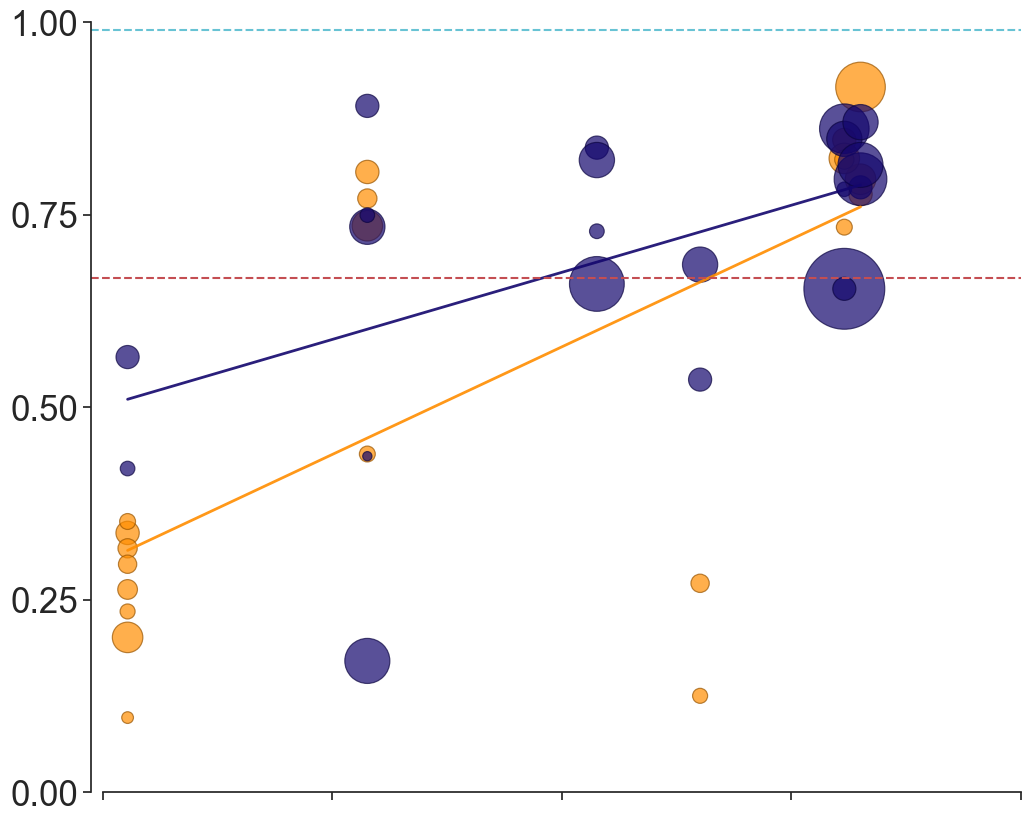

In [45]:
symbolic_corr = 0.667
noise_ceiling = 0.99
def adjust_lightness(color, amount=0.5):
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], c[1] * amount, c[2])

palette = {

    ('cnn'): '#ff8d00',
    ('vit'): '#13066d',  
 
}
df_plot['color'] = df_plot.apply(lambda row: palette[(row['backbone'])], axis=1)
df_plot['edge_color']  = [adjust_lightness(color, 0.6) for color in list(df_plot['color'])]

scale_factor = 700
# Plotting with custom colors
sns.set(style='white')
fig, ax = plt.subplots(figsize= (12, 10))
for (train), group_data in df_plot.groupby(['backbone']):
    sns.scatterplot(
        data=group_data,
        x='train_set_size',
        y='correlation',
        color=group_data['color'].iloc[0],
        edgecolor=group_data['edge_color'].iloc[0],
        s=group_data['power_number_parameters'] /scale_factor,  # Size proportional to number_parameters
        alpha=0.7,
        legend=False
    )

# size_legend_params = [30_000_000, 150_000_000, 1_000_000_000]  # adjust based on your actual model sizes
# size_legend_dots = [np.power(s, chosen_power)/scale_factor for s in size_legend_params]

# legend_elements = [
#     plt.scatter([], [], s=size, color='gray', alpha=0.5, edgecolors='none',
#                 label=f'{p/1e9:.1f}B params' if p >= 1e9 else f'{int(p/1e6)}M params')
#     for size, p in zip(size_legend_dots, size_legend_params)
# ]

# # Place the legend
# ax.legend(
#     handles=legend_elements,
#     title='Model size',
#     loc='lower right',
#     fontsize=25,
#     title_fontsize=25,
#     handleheight=2,
#     labelspacing=1.5,
#     frameon=False
# )


for backbone, group_data in df_plot.groupby("backbone"):
    # Log-transform X
    X = np.log10(group_data["train_set_size"]).values.reshape(-1, 1)
    y = group_data["correlation"].values

    # Fit regression
    reg = LinearRegression().fit(X, y)

    # Make smooth prediction line
    x_range = np.linspace(group_data["train_set_size"].min(),
                          group_data["train_set_size"].max(), 200)
    x_range_log = np.log10(x_range).reshape(-1, 1)
    y_pred = reg.predict(x_range_log)

    # Plot regression line with the same color as the scatter
    ax.plot(
        x_range,
        y_pred,
        color=palette[backbone],
        linewidth=2,
        linestyle="-",
        alpha=0.9,
    )
handles, labels = [],[]
plt.xscale('log')
# Customize labels and ticks
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticks([1e6, 1e7, 1e8, 1e9, 1e10])
yticks = ax.get_yticklabels()
xticks = ax.get_xticklabels()
print(xticks)
noise_ceiling = 0.99
plt.axhline(y=symbolic_corr, color='r', linestyle='--',)
plt.axhline(y=noise_ceiling, color='#68C3D4', linestyle='--',)

ax.set_ylabel("")
ax.set_xlabel("")

ax.set_yticklabels(yticks, size=25)
ax.set_xticklabels([], size=25)

ax.spines['left'].set_bounds(0, 1.0)
ax.spines['bottom'].set_bounds(1e6, 1e10)
ax.tick_params(left=True, bottom=True)

sns.despine()
plt.rcParams['svg.fonttype'] = 'none'
fig.savefig('plots/figure_rsa_quadri_correlation.svg', format='svg')

In [46]:
features = ['number_parameters', 'train_set_size', 'backbone', 'training_method']
target = 'correlation'
# df_plot = pd.read_csv('all_cors.csv')
# One-hot encode categorical variables: backbone and training_method
df_features = pd.get_dummies(
    df_plot[features],
    columns=['backbone', 'training_method'],
    drop_first=False
)

# Standardize numerical features
scaler = StandardScaler()
df_features[['number_parameters', 'train_set_size']] = scaler.fit_transform(
    df_features[['number_parameters', 'train_set_size']]
)

X = df_features
y = df_plot[target]

color_significant = '#5A509B'
color_non_significant = '#888'

# Fit Ridge regression
model = Ridge(alpha=1e-2).fit(X, y)
print(model.score(X, y))

def grouped_permutation_importance(model, X, y, groups, n_repeats=30, random_state=0):
    rng = np.random.RandomState(random_state)
    baseline_score = model.score(X, y)
    n_groups = len(groups)

    importances = {}

    for group in groups:
        print(group)
        scores = []
        for _ in range(n_repeats):
            X_permuted = X.copy()
            # permute all columns in this group together
            idx = rng.permutation(len(X))
            X_permuted[group] = X_permuted[group].iloc[idx].values
            scores.append(model.score(X_permuted, y))

        scores = np.array([float(s) for s in scores])
        drops = baseline_score - scores
        mean_drop = np.mean(drops)
        std_drop = np.std(drops)


        m = len(groups)  # number of features
        alpha = 0.05

        # Bonferroni-adjusted z threshold
        z_adj = norm.ppf(1 - alpha / (2*m))
      
        significant = abs(mean_drop) > z_adj * std_drop

        importances[group[0]] = {'mean': mean_drop, 'std': std_drop, 'significant':significant}
       
    return importances



# Example: group dummies for training_method
groups = [
    [col for col in X.columns if col.startswith("training_method_")],
    [col for col in X.columns if col.startswith("backbone_")],
    ['number_parameters'],
    ['train_set_size']
]

importances = grouped_permutation_importance(model, X, y, groups)
feature_importance = pd.DataFrame(importances)
print(feature_importance)
feature_importance2 = feature_importance.T
# Assign colors
feature_importance2['Color'] = feature_importance2['significant'].map(
    {True: color_significant, False: color_non_significant}
)
feature_importance2['Feature'] = feature_importance2.index
feature_importance2.reset_index()

print(feature_importance2)
feature_importance2
feature_importance2.to_csv('temp.csv')

0.48184457888170373
['training_method_clip', 'training_method_supervised', 'training_method_unsupervised']
['backbone_cnn', 'backbone_vit']
['number_parameters']
['train_set_size']
            training_method_clip backbone_cnn number_parameters train_set_size
mean                    0.081658     0.176157           0.03915       0.683012
std                     0.034373     0.070229          0.025176         0.1531
significant                False         True             False           True
                          mean       std significant    Color  \
training_method_clip  0.081658  0.034373       False     #888   
backbone_cnn          0.176157  0.070229        True  #5A509B   
number_parameters      0.03915  0.025176       False     #888   
train_set_size        0.683012    0.1531        True  #5A509B   

                                   Feature  
training_method_clip  training_method_clip  
backbone_cnn                  backbone_cnn  
number_parameters        number_parameters

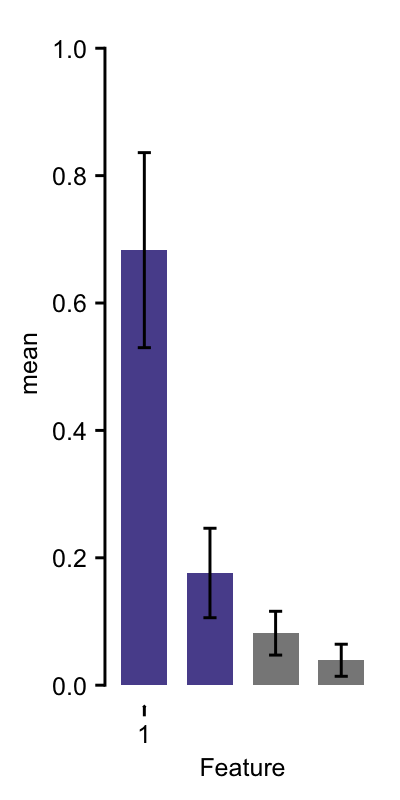

In [48]:
%%R -w 2 -h 4  --units in -r 200

feature_importance <- read.csv('temp.csv')
feature_importance <- feature_importance %>%
  arrange(desc(mean))

feature_importance$Feature <- factor(feature_importance$Feature, levels = feature_importance$Feature)

# Create the ggplot2 bar plot
p <- ggplot(feature_importance, aes(x = Feature, y = mean, fill = Color)) +
    geom_col(width = 0.7) + # geom_col for pre-computed heights, width adjusts bar thickness
    geom_errorbar(
      aes(ymin = mean - std, ymax = mean + std),
      width = 0.2, # Adjust the width of the error bar caps
      color = "black" # Color of the error bars
    ) +

    scale_fill_identity() + # Use the 'Color' column directly for fill
    # Customizing the theme for a "prettier" look and removing top/right spines
    # theme_minimal() + # Start with a minimal theme
    theme(
      panel.grid.major = element_blank(), # Remove major grid lines
      panel.grid.minor = element_blank(), # Remove minor grid lines
      panel.background = element_blank(), 
      panel.grid.major.y = element_blank(),

    ) +
    # Set y-axis limits and breaks similar to your Python code
    # The Python y-axis was inverted, but for means, a standard positive up is usually preferred.
    # If you truly want to invert, you'd use scale_y_reverse().
  

    guides(x = guide_axis_manual(trunc_lower=1, trunc_upper=1, breaks=c(1)),
          y = guide_axis_manual(trunc_lower=0, trunc_upper=1.0, breaks=seq(0,1.0,0.2))) +


    coord_cartesian(ylim = c(min(feature_importance$mean - feature_importance$std) * 1.1,
                            max(feature_importance$mean + feature_importance$std) * 1.1 + max(feature_importance$std) * 0.5)
                    )  # This helps control the visible range without dropping data

  
    # coord_flip(ylim = c(
    #   min(feature_importance$mean - feature_importance$std) * 1.1,
    #   max(feature_importance$mean + feature_importance$std) * 1.1 + max(feature_importance$std) * 0.5
    # ))
  
ggsave("plots/feature_importance_correlation.svg", p, device='svg',width = 2, height = 4, units = "in")
p

# Table with all models

In [50]:
df = pd.read_csv('all_cors.csv')

In [51]:
df = df[['model', 'number_parameters', 'train_set','backbone', 'training_method']]

In [52]:
df.to_csv('models_attributes.csv', sep=";")